# 02: Limpieza, EDA y Feature Engineering
## EduRisk: Early Student Dropout Prediction

Objetivo: limpiar los datos, explorar su estructura y crear nuevas features
sobre las 24 variables de matrícula (Grupo A) antes del modelado.

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import hashlib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) # Mostrar todas las columnas
plt.rcParams['figure.figsize'] = (10, 5) # Configurar tamaño de las figuras para no repetirlo cada vez figure(figsize=(10, 5))
# sns.set_theme(style='whitegrid') # Configurar el estilo de los gráficos para no repetirlo cada vez sns.set_theme(style='whitegrid')

In [127]:
# __file__ no existe en notebooks, usamos Path.cwd()
NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent  # sube un nivel desde notebooks/

DATA_RAW = ROOT / 'data' / 'raw' / 'data.csv'

df = pd.read_csv(DATA_RAW)
print(f"Shape: {df.shape}")

# Columnas Grupo B, rendimiento POST-matrícula, no disponibles en día 0
COLS_DROP = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
]

df.drop(columns=COLS_DROP, inplace=True)

print(f"Shape tras drop Grupo B: {df.shape}")  # debe dar (4424, 25)
print(f"Columnas restantes:")
for col in df.columns:
    print(f" - {col}")

Shape: (4424, 37)
Shape tras drop Grupo B: (4424, 25)
Columnas restantes:
 - Marital Status
 - Application mode
 - Application order
 - Course
 - Daytime/evening attendance
 - Previous qualification
 - Previous qualification (grade)
 - Nacionality
 - Mother's qualification
 - Father's qualification
 - Mother's occupation
 - Father's occupation
 - Admission grade
 - Displaced
 - Educational special needs
 - Debtor
 - Tuition fees up to date
 - Gender
 - Scholarship holder
 - Age at enrollment
 - International
 - Unemployment rate
 - Inflation rate
 - GDP
 - Target


## 1. Limpieza

In [128]:
print("=== Missing values ===")
print(df.isnull().sum())

print(f"\n=== Duplicados: {df.duplicated().sum()} ===")

=== Missing values ===
Marital Status                    0
Application mode                  0
Application order                 0
Course                            0
Daytime/evening attendance        0
Previous qualification            0
Previous qualification (grade)    0
Nacionality                       0
Mother's qualification            0
Father's qualification            0
Mother's occupation               0
Father's occupation               0
Admission grade                   0
Displaced                         0
Educational special needs         0
Debtor                            0
Tuition fees up to date           0
Gender                            0
Scholarship holder                0
Age at enrollment                 0
International                     0
Unemployment rate                 0
Inflation rate                    0
GDP                               0
Target                            0
dtype: int64

=== Duplicados: 0 ===


=== Distribución del Target ===
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


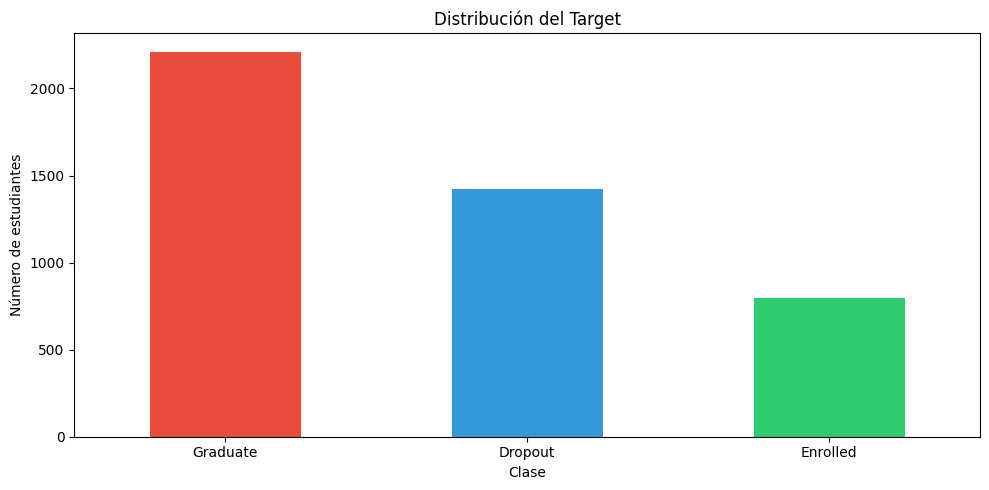

In [129]:
print("=== Distribución del Target ===")
print(df['Target'].value_counts())
print(df['Target'].value_counts(normalize=True).round(3))

df['Target'].value_counts().plot(kind='bar', color=['#e74c3c','#3498db','#2ecc71'])
plt.title('Distribución del Target')
plt.xlabel('Clase')
plt.ylabel('Número de estudiantes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Decisión: desbalance de clases

| Clase | Significado | N | % |
|---|---|---|---|
| Graduate | Graduado: Terminó la carrera | 2.209 | 49.9% |
| Dropout | Abandono: Dejó la carrera | 1.421 | 32.1% |
| Enrolled | Matriculado: Sigue cursando | 794 | 17.9% |

**Nota:** Enrolled es la clase más ambigua, son estudiantes que en el
momento de recogida de datos aún estaban cursando. 
<br>No se sabe si acabarán graduándose o abandonando.

El desbalance existe pero es moderado, **no** requiere SMOTE.
Estrategia: usar `class_weight='balanced'` en todos los modelos
que lo soporten.
<br>Esto penaliza más los errores en clases minoritarias
(especialmente Enrolled) sin generar datos sintéticos.
<br>La métrica principal será **F1-weighted** por ser multiclase desbalanceado.

**Métrica principal: F1-weighted**  
En problemas multiclase con desbalance, el F1-score estándar no es
suficiente. 
<br>El F1-weighted calcula el F1 de cada clase por separado
y luego hace una media ponderada por el número de ejemplos de cada
clase. 
<br>Así Graduate (50%) no infla la métrica ni Enrolled (18%) la
hunde, cada clase contribuye proporcionalmente a su frecuencia real.

In [130]:
TARGET_MAP = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2} # Constante para mapear el target a números
df_model = df.copy()
df_model['Target'] = df_model['Target'].map(TARGET_MAP)

print("Target codificado:")
print(df_model['Target'].value_counts().sort_index())

Target codificado:
Target
0    1421
1     794
2    2209
Name: count, dtype: int64


## 2. EDA – Análisis Exploratorio

In [131]:
print("Tipos de datos")
print(df.dtypes)

Tipos de datos
Marital Status                      int64
Application mode                    int64
Application order                   int64
Course                              int64
Daytime/evening attendance          int64
Previous qualification              int64
Previous qualification (grade)    float64
Nacionality                         int64
Mother's qualification              int64
Father's qualification              int64
Mother's occupation                 int64
Father's occupation                 int64
Admission grade                   float64
Displaced                           int64
Educational special needs           int64
Debtor                              int64
Tuition fees up to date             int64
Gender                              int64
Scholarship holder                  int64
Age at enrollment                   int64
International                       int64
Unemployment rate                 float64
Inflation rate                    float64
GDP                

In [132]:
print(f"Shape: {df.shape}")

Shape: (4424, 25)


In [133]:
df.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,16.200000,3.700000,3.510000


### 2.1 Distribuciones de variables continuas

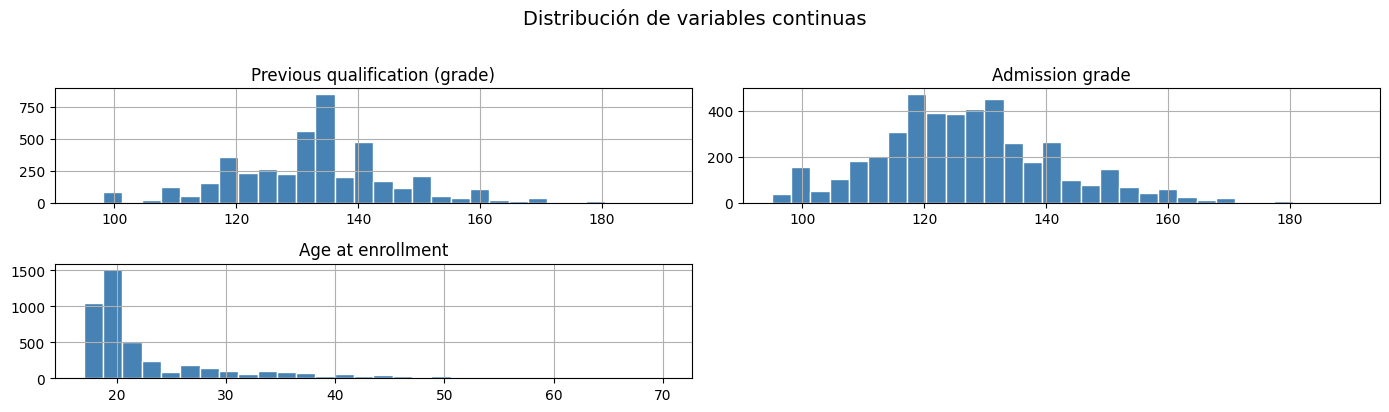

In [134]:
# Solo estas tres son verdaderamente continuas
CONTINUOUS = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
]

# Gráfico variables continuas
df[CONTINUOUS].hist(bins=30, figsize=(14, 4), color='steelblue', edgecolor='white')
plt.suptitle('Distribución de variables continuas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



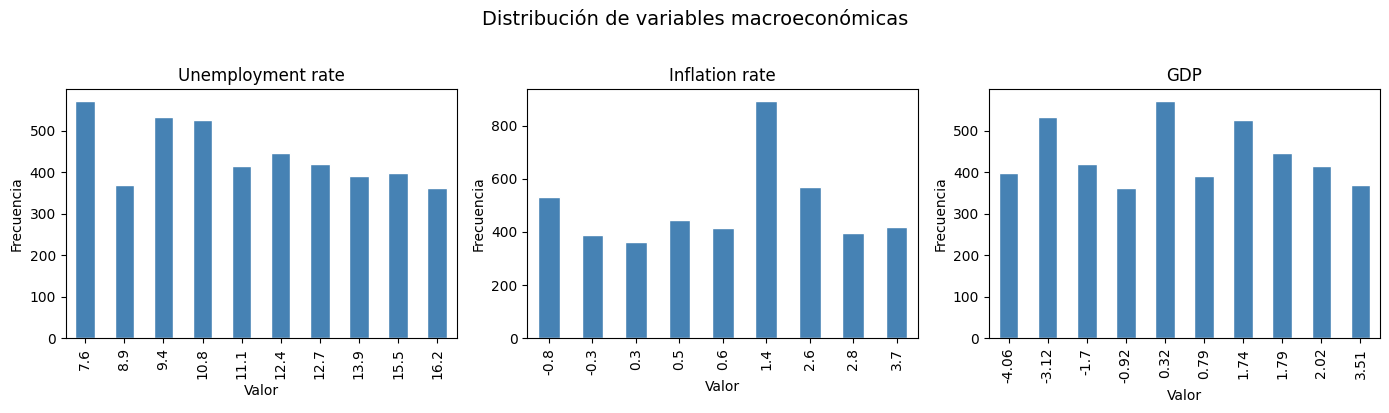

In [135]:
# Estas son discretas con pocos valores — contexto macroeconómico
MACRO = [
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]
# Gráfico variables macro — son discretas, usamos countplot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, MACRO):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribución de variables macroeconómicas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [136]:
print("Skewness (asimetría)")
print(df[CONTINUOUS].skew().round(3))

print("\nKurtosis (forma de la distribución)")
print(df[CONTINUOUS].kurtosis().round(3))

Skewness (asimetría)
Previous qualification (grade)    0.313
Admission grade                   0.531
Age at enrollment                 2.055
dtype: float64

Kurtosis (forma de la distribución)
Previous qualification (grade)    0.968
Admission grade                   0.663
Age at enrollment                 4.127
dtype: float64


### Observaciones para variables continuas

| Variable | Skewness | Kurtosis | Interpretación |
|---|---|---|---|
| `Previous qualification (grade)` | 0.313 | 0.968 | Distribución casi simétrica con ligera cola derecha. Sin problemas para modelado. |
| `Admission grade` | 0.531 | 0.663 | Sesgo positivo leve, distribución aceptable. Concentrada entre 100-150. |
| `Age at enrollment` | **2.055** | **4.127** | Sesgo alto y pico muy pronunciado. La mayoría son jóvenes (17-22 años) con outliers reales de estudiantes mayores (hasta 70 años). No se eliminan, son casos válidos. Se creará `age_group` en Feature Engineering. |

### Observaciones para variables macroeconómicas

| Variable | Valores únicos | Skewness | Kurtosis | Interpretación |
|---|---|---|---|---|
| `Unemployment rate` | 10 | 0.212 | -0.996 | Distribución plana y uniforme, todos los años académicos tienen representación similar. |
| `Inflation rate` | 9 | 0.252 | -1.039 | Kurtosis negativa confirma distribución plana (platicúrtica). |
| `GDP` | 10 | -0.394 | -1.002 | Ligera cola izquierda, distribución plana. Años de contracción económica bien representados. |

**Conclusión:** Solo `Age at enrollment` requiere tratamiento,
se creará una feature `age_group` en la sección de **Feature Engineering**.
<br>Las variables macro se mantienen tal cual: su distribución plana
es coherente con su naturaleza (un valor por año académico, no por estudiante).

### 2.2 Análisis bivariante – Variables continuas vs Target

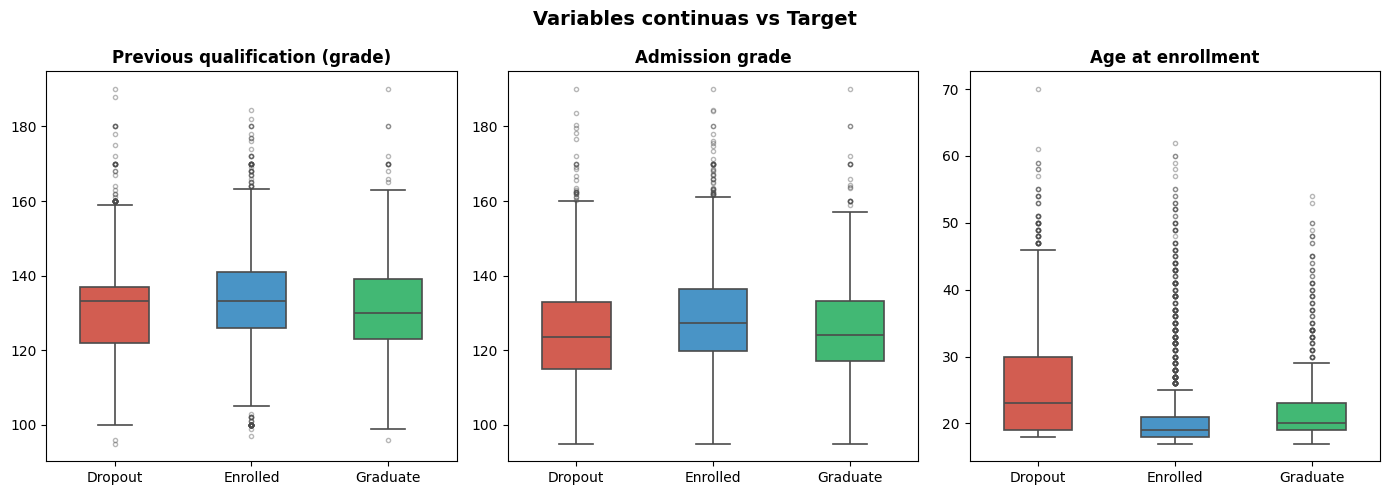

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, col in zip(axes, CONTINUOUS):
    sns.boxplot(
        data=df, x='Target', y=col, ax=ax,
        palette=colors,
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Dropout', 'Enrolled', 'Graduate'])
    ax.set_ylabel('')

plt.suptitle('Variables continuas vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones – Variables continuas vs Target

- **Previous qualification (grade)**: Las tres clases tienen medianas
  similares (~130). Poca capacidad discriminante por sí sola.

- **Admission grade**: ,edianas similares entre clases (~122-128).
  Capacidad discriminante baja por sí sola.

- **Age at enrollment**: La variable más discriminante de las tres.
  Dropout tiene mediana ~24 años y caja más amplia, mayor variedad
  de edades. Enrolled y Graduate se concentran en edades jóvenes
  (mediana ~19-20 años). **Los estudiantes mayores tienen mayor
  tendencia al abandono**.

**Conclusión**: Ninguna variable continua discrimina fuertemente
por sí sola. El modelo necesitará combinar múltiples features
para detectar patrones, justifica el uso de un ensemble como
XGBoost y Random Forest.

### 2.3 Análisis bivariante – Variables binarias vs Target

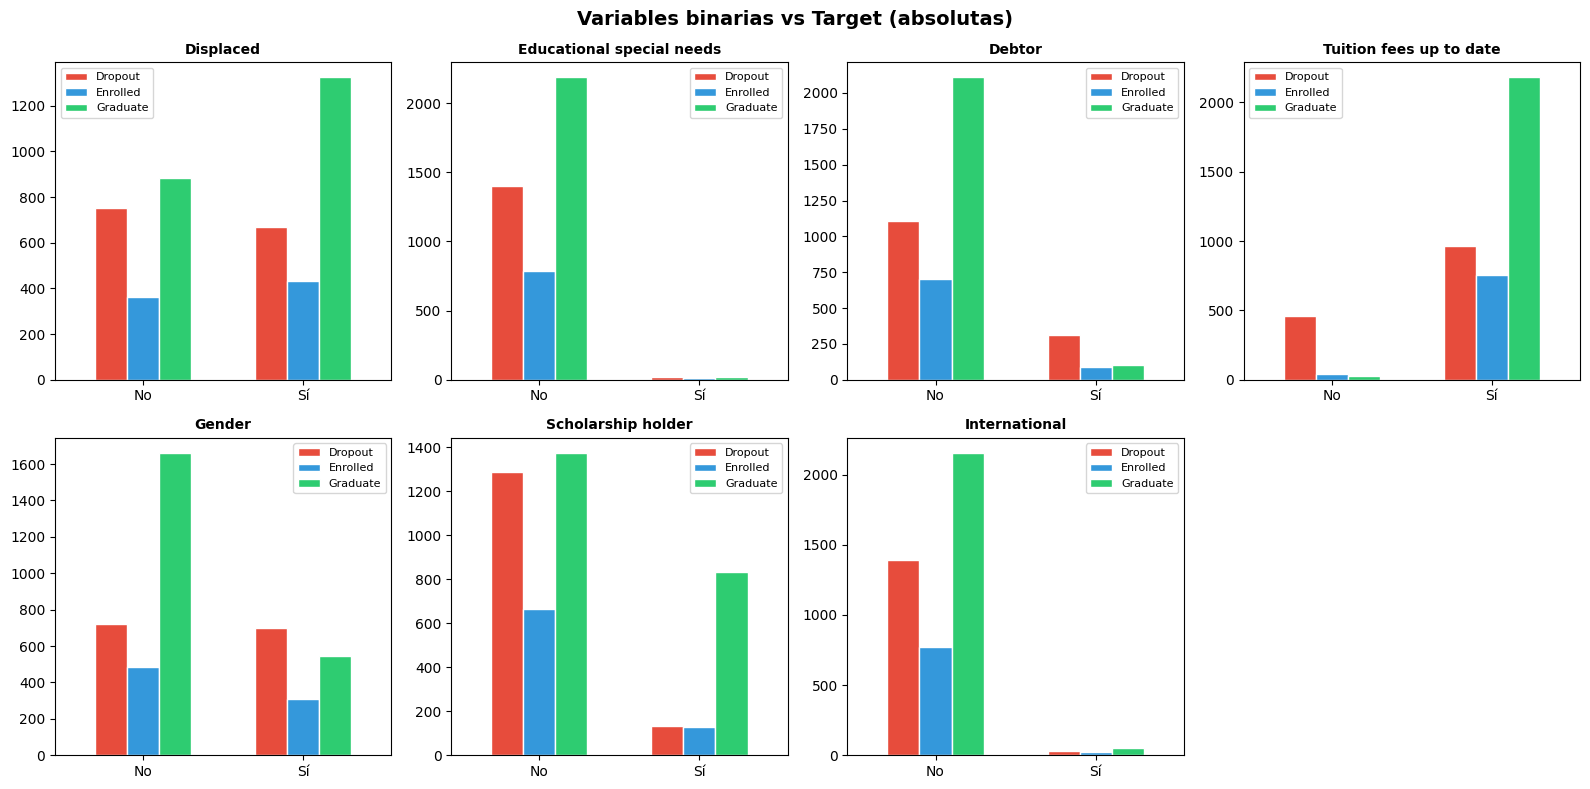

In [138]:
BINARY = [
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender',
    'Scholarship holder', 'International'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(BINARY):
    ct = df.groupby([col, 'Target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=colors, width=0.6, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No', 'Sí'], rotation=0)
    axes[i].legend(['Dropout', 'Enrolled', 'Graduate'], fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Variables binarias vs Target (absolutas)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

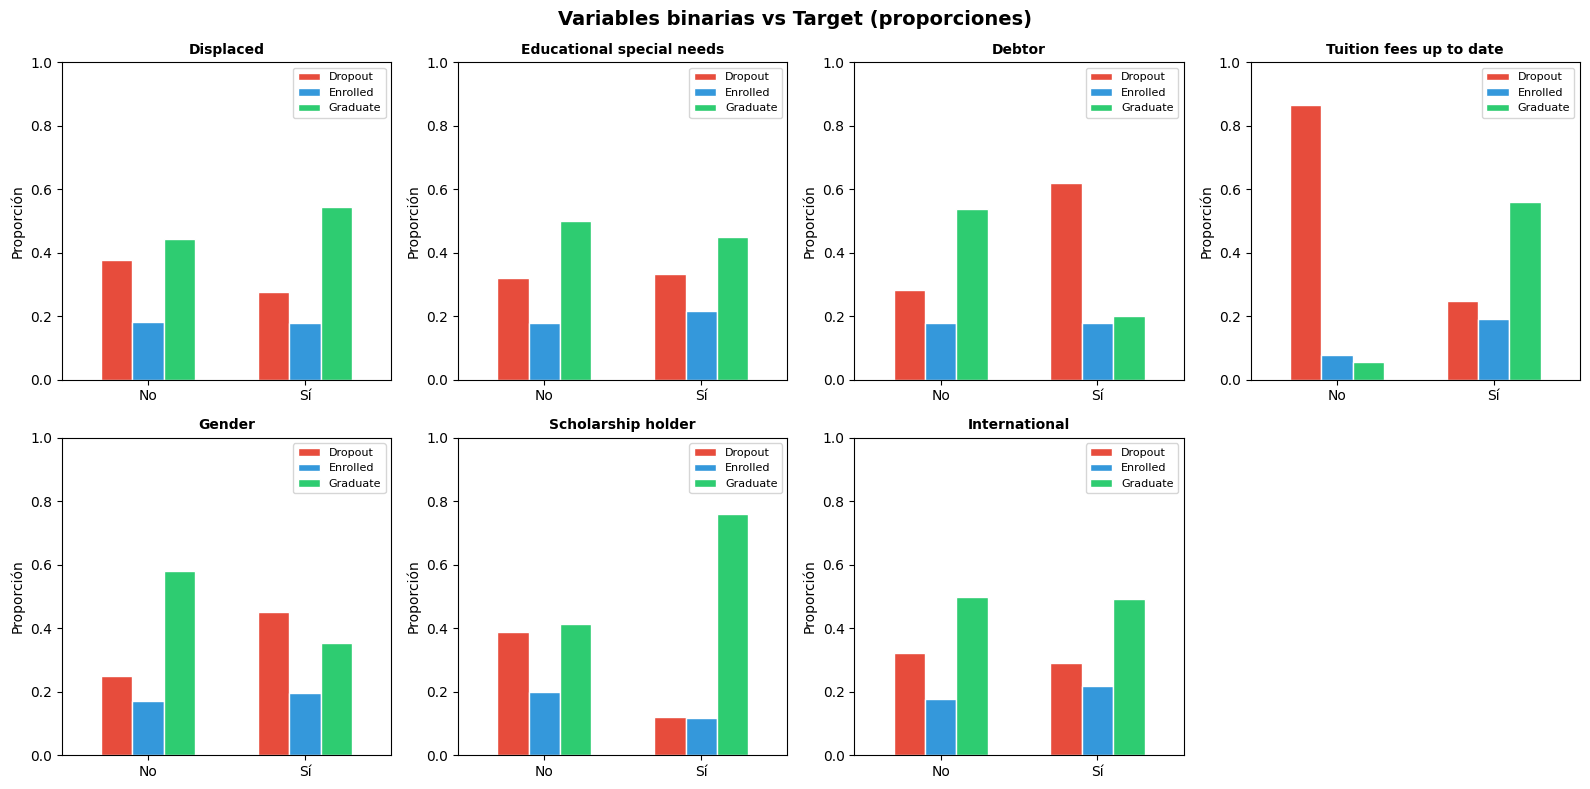

In [139]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(BINARY):
    ct = df.groupby([col, 'Target']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.plot(kind='bar', ax=axes[i], color=colors, width=0.6, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No', 'Sí'], rotation=0)
    axes[i].set_ylabel('Proporción')
    axes[i].legend(['Dropout', 'Enrolled', 'Graduate'], fontsize=8)
    axes[i].set_ylim(0, 1)

axes[-1].set_visible(False)
plt.suptitle('Variables binarias vs Target (proporciones)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [140]:
for col in BINARY:
    print(f"\n{col}")
    ct = df.groupby([col, 'Target']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0).round(3)
    print(ct_pct)


Displaced
Target     Dropout  Enrolled  Graduate
Displaced                             
0            0.376     0.181     0.443
1            0.276     0.178     0.546

Educational special needs
Target                     Dropout  Enrolled  Graduate
Educational special needs                             
0                            0.321     0.179     0.500
1                            0.333     0.216     0.451

Debtor
Target  Dropout  Enrolled  Graduate
Debtor                             
0         0.283     0.180     0.538
1         0.620     0.179     0.201

Tuition fees up to date
Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
0                          0.866     0.080     0.055
1                          0.247     0.193     0.560

Gender
Target  Dropout  Enrolled  Graduate
Gender                             
0         0.251     0.170     0.579
1         0.451     0.197     0.352

Scholarship holder
Target              Dropo

### Observaciones – Variables binarias vs Target (proporciones)

| Variable | Observación | Discriminante |
|---|---|---|
| `Displaced` | Dropout baja de 37.6% a 27.6% si está desplazado. Diferencia leve. | Baja |
| `Educational special needs` | Proporciones casi idénticas en Sí/No. | Muy baja |
| `Debtor` | Dropout sube de 28.3% a 62.0% si tiene deudas. | **Muy alta** |
| `Tuition fees up to date` | Dropout del 86.6% si NO está al día. Solo 24.7% si sí lo está. | **Muy alta** |
| `Gender` | Hombres (Sí): 45.1% Dropout vs Mujeres (No): 25.1%. | Media |
| `Scholarship holder` | Becados: 12.2% Dropout vs 38.7% sin beca. Becados se gradúan más (76%). | **Alta** |
| `International` | Proporciones casi idénticas — confirma baja discriminación. | Muy baja |

**Conclusiones:**
- Riesgo financiero (`Debtor` + `Tuition fees up to date`) son
  los predictores más fuertes de abandono.
- `Scholarship holder` protege fuertemente contra el abandono.
- `Educational special needs` e `International` aportan muy poco
  al modelo.
- Los gráficos de proporciones confirman lo observado en los
  números, evitando el sesgo visual de los valores absolutos.

### 2.4 Heatmap de correlaciones

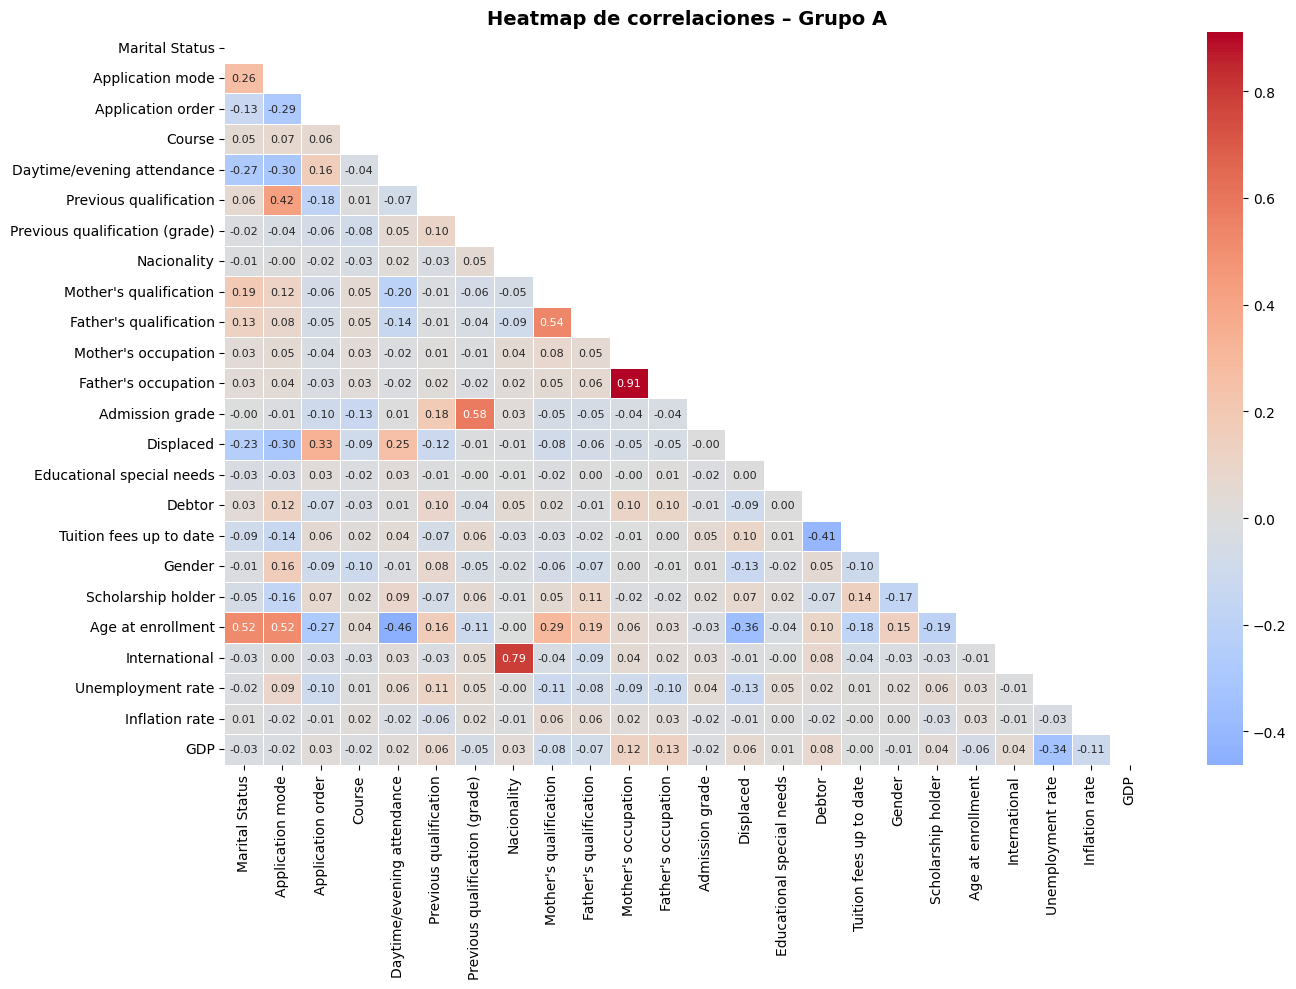

In [141]:
plt.figure(figsize=(14, 10))
corr = df.drop(columns=['Target']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Heatmap de correlaciones – Grupo A', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

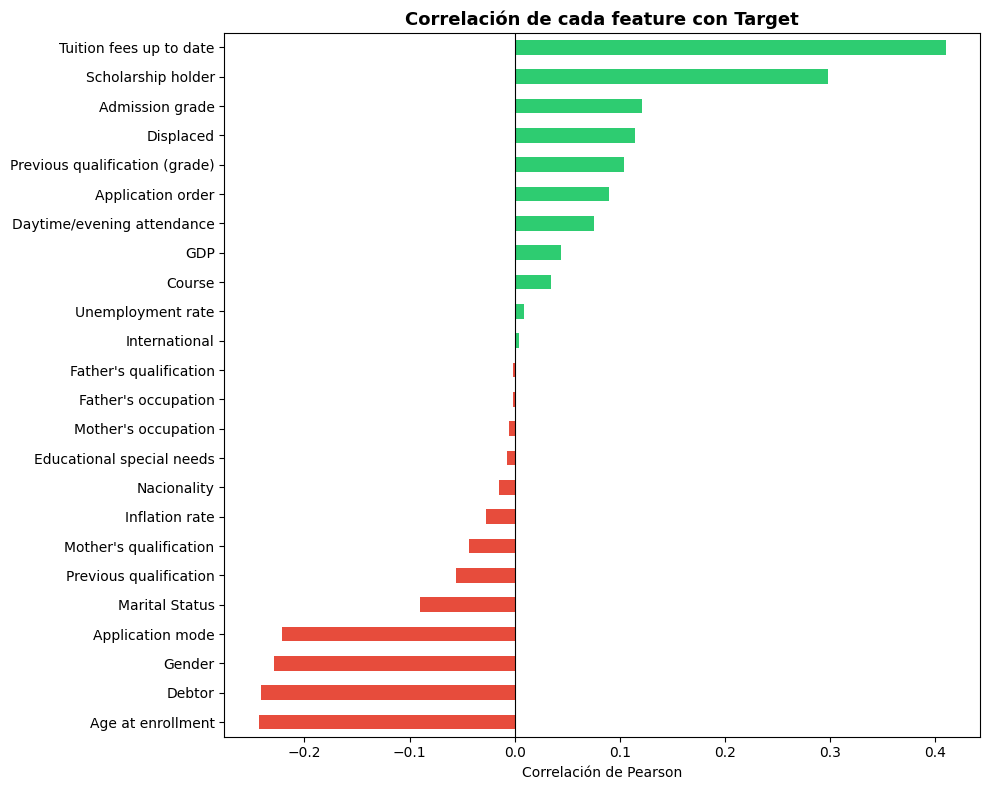

Age at enrollment                -0.243
Debtor                           -0.241
Gender                           -0.229
Application mode                 -0.222
Marital Status                   -0.090
Previous qualification           -0.056
Mother's qualification           -0.043
Inflation rate                   -0.027
Nacionality                      -0.015
Educational special needs        -0.007
Mother's occupation              -0.006
Father's occupation              -0.002
Father's qualification           -0.001
International                     0.004
Unemployment rate                 0.009
Course                            0.034
GDP                               0.044
Daytime/evening attendance        0.075
Application order                 0.090
Previous qualification (grade)    0.104
Displaced                         0.114
Admission grade                   0.121
Scholarship holder                0.298
Tuition fees up to date           0.410
Name: Target_encoded, dtype: float64


In [142]:
# Correlación de cada feature con el target codificado
TARGET_MAP = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_encoded'] = df['Target'].map(TARGET_MAP)

corr_target = df.drop(columns=['Target']).corr()['Target_encoded'].drop('Target_encoded').sort_values()

plt.figure(figsize=(10, 8))
corr_target.plot(kind='barh', color=corr_target.map(lambda x: '#e74c3c' if x < 0 else '#2ecc71'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada feature con Target', fontsize=13, fontweight='bold')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print(corr_target.round(3))

### Observaciones en el Heatmap de correlaciones

**Correlaciones altas destacadas:**

| Par | Correlación | Nota |
|---|---|---|
| `Mother's occupation` / `Father's occupation` | 0.91 | Multicolinealidad muy alta, ambas miden el mismo concepto (nivel socioeconómico familiar). Se creará una feature combinada en FE. |
| `International` / `Nacionality` | 0.79 | Redundancia esperada. Se mantendrán ambas pero con bajo peso esperado. |
| `Admission grade` / `Previous qualification (grade)` | 0.58 | Correlación lógica, rendimiento previo predice nota de admisión. |
| `Mother's qualification` / `Father's qualification` | 0.54 | Multicolinealidad moderada, misma lógica que las ocupaciones. |
| `Age at enrollment` / `Marital Status` | 0.52 | Estudiantes mayores tienden a estar casados. |
| `Debtor` / `Tuition fees up to date` | -0.41 | Correlación negativa esperada, quien debe no está al día. |

**Decisión sobre multicolinealidad:**
`Mother's occupation` y `Father's occupation` tienen correlación 0.91,
se combinarán en una sola feature `parents_occupation_avg` en Feature
Engineering. La misma decisión aplica para `Mother's qualification` y
`Father's qualification` (correlación 0.54) que se combinarán en
`parents_qualification_avg`. Ambas decisiones reducen multicolinealidad
sin perder información.

---

### Correlación de features con Target

**Limitación importante**: correlación de Pearson asume linealidad.
El target codificado (0=Dropout, 1=Enrolled, 2=Graduate) es ordinal
arbitrario, esta correlación es orientativa, no definitiva.
El ranking real de importancia se calculará con SHAP en el notebook 03.

**Correlación positiva** (verde) → valores más altos de la variable
se asocian con Graduate.
**Correlación negativa** (rojo) → valores más altos se asocian
con Dropout.

| Ranking | Variable | Correlación | Interpretación |
|---|---|---|---|
| 1 | `Tuition fees up to date` | +0.410 | Pagar la matrícula = mayor probabilidad de graduarse |
| 2 | `Scholarship holder` | +0.298 | Tener beca protege contra el abandono |
| 3 | `Admission grade` | +0.121 | Mejor nota de entrada = más probabilidad de graduarse |
| 4 | `Displaced` | +0.114 | Desplazados tienden ligeramente a graduarse más |
| 5 | `Previous qualification (grade)` | +0.104 | Mejor nota previa = más probabilidad de graduarse |
| 6 | `Application order` | +0.090 | Primera opción de carrera = más motivación |
| 7 | `Daytime/evening attendance` | +0.075 | Turno diurno se asocia ligeramente con graduarse |
| 8 | `Age at enrollment` | -0.243 | Mayor edad = más riesgo de abandono |
| 9 | `Debtor` | -0.241 | Tener deudas = más riesgo de abandono |
| 10 | `Gender` | -0.229 | Hombres tienen más tendencia al abandono |
| 11 | `Application mode` | -0.222 | Ciertas vías de acceso se asocian con más abandono |
| 12 | `Marital Status` | -0.090 | Estudiantes casados tienden más al abandono |

**Variables con correlación casi nula** (|r| < 0.02):
`Mother's occupation`, `Father's occupation`, `Father's qualification`,
`Mother's qualification`, su impacto es indirecto y no lineal.
El modelo los captará mejor que Pearson.

**Confirmación**: los resultados son consistentes con el análisis
bivariante previo, `Tuition fees up to date`, `Debtor` y
`Scholarship holder` son las variables más relevantes.

## 3. Feature Engineering

### 3.1 Codificación del target

In [143]:
TARGET_MAP = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target'] = df['Target'].map(TARGET_MAP)

# Eliminamos la columna auxiliar que creamos para la correlación
if 'Target_encoded' in df.columns:
    df.drop(columns=['Target_encoded'], inplace=True)

print("Target codificado:")
print(df['Target'].value_counts().sort_index())
print(f"\nShape: {df.shape}")

Target codificado:
Target
0    1421
1     794
2    2209
Name: count, dtype: int64

Shape: (4424, 25)


### 3.2 Nuevas features
Las siguientes features se crean a partir de las variables existentes
para reducir multicolinealidad y capturar patrones de negocio relevantes.

In [144]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# 1. Nivel educativo promedio de los padres
df['parents_qualification_avg'] = (
    df["Mother's qualification"] + df["Father's qualification"]
) / 2

# 2. Riesgo financiero combinado (0=sin riesgo, 1=moderado, 2=alto)
df['financial_risk'] = (
    df['Debtor'] + (1 - df['Tuition fees up to date'])
)

# 3. Grupo de edad
df['age_group'] = pd.cut(
    df['Age at enrollment'],
    bins=[0, 20, 25, 35, 100],
    labels=[0, 1, 2, 3]
).astype(int)

# 4. Primera opción de carrera
df['is_first_choice'] = (df['Application order'] == 1).astype(int)

# ============================================================
# VERIFICACIÓN
# ============================================================
print(f"Shape final: {df.shape}")
print(f"\nFeatures nuevas:")
print(df[['parents_qualification_avg', 'financial_risk',
          'age_group', 'is_first_choice']].describe().round(2))

Shape final: (4424, 29)

Features nuevas:
       parents_qualification_avg  financial_risk  age_group  is_first_choice
count                    4424.00         4424.00    4424.00          4424.00
mean                       20.92            0.23       0.75             0.68
std                        13.56            0.54       1.01             0.46
min                         1.00            0.00       0.00             0.00
25%                        10.00            0.00       0.00             0.00
50%                        19.50            0.00       0.00             1.00
75%                        37.00            0.00       1.00             1.00
max                        42.00            2.00       3.00             1.00


### Nuevas features creadas

| Feature | Basada en | Justificación |
|---|---|---|
| `parents_qualification_avg` | `Mother's qualification` + `Father's qualification` | Reduce multicolinealidad (correlación entre ambas = 0.54). Captura el nivel educativo familiar como concepto único. |
| `financial_risk` | `Debtor` + `Tuition fees up to date` | Combina los dos indicadores financieros más discriminantes del análisis bivariante. Valores: 0=sin riesgo, 1=riesgo moderado, 2=riesgo alto. |
| `age_group` | `Age at enrollment` | Captura la distribución no lineal de la edad (skewness=2.05) en grupos: 0=hasta 20 años, 1=21-25, 2=26-35, 3=más de 35. |
| `is_first_choice` | `Application order` | 1 si esta carrera era la primera opción del estudiante. Proxy de motivación. El 68% eligió esta carrera como primera opción. |

  **Decisiones sobre features originales:**
- `Mother's occupation` y `Father's occupation` se mantienen en el
  dataset. Se creó `parents_qualification_avg` como feature adicional
  pero no reemplaza a las originales.
- `parents_occupation_avg` se descartó durante el proceso porque
  los códigos de ocupación son arbitrarios sin orden lógico,
  el promedio no tiene sentido de negocio.
- `is_first_choice` se corrigió de `== 0` (1 estudiante) a `== 1`
  (3.026 estudiantes) que representa la primera opción real.

In [145]:
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_path = PROCESSED_DIR / 'data_processed.parquet'
checksum_path  = PROCESSED_DIR / 'data_processed.parquet.sha256'

# Guardar parquet
df.to_parquet(processed_path, index=False)

# Checksum
h = hashlib.sha256()
with open(processed_path, 'rb') as f:
    for chunk in iter(lambda: f.read(8192), b''):
        h.update(chunk)
checksum = h.hexdigest()
checksum_path.write_text(checksum)

print(f"Guardado!")
print(f"Shape: {df.shape}")
print(f"SHA256: {checksum}")

Guardado!
Shape: (4424, 29)
SHA256: 4bf9e2e234657269ba9c65855dd2a24d218d68eccf5e55fd2a001cbb6301e0ce


## Conclusión del notebook 02

- Dataset limpio: 0 missing values, 0 duplicados
- Drop de 12 features post-matrícula (Grupo B)
- 4 features nuevas creadas: `parents_qualification_avg`,
  `financial_risk`, `age_group`, `is_first_choice`
- Shape final: 4.424 filas x 29 columnas
- Datos procesados guardados en `data/processed/data_processed.parquet`
- El modelado se realiza en `03_Entrenamiento_Evaluacion.ipynb`